## Setup

In [1]:
import numpy as np

param_path = 'D:/data/base_cmr_parameters.json'

trial, presentation = (
    np.array([ 1,  2,  3,  4,  5,  6,  7,  9, 10, 11, 17, 14, 12, 15, 25, 20, 28,
            30, 39, 38, 37, 18,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
            0,  0,  0,  0,  0,  0]),
    np.array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 12, 13, 14, 15, 16,
            17, 10, 18, 19, 20, 19, 21, 22, 23, 20, 24, 25, 26, 22, 27, 28, 24,
            29, 30, 31, 32, 33, 34]))

item_count = np.max(presentation)
item_count
list_length = 40

## Numba Implementation

Pre-retrieval
[2.27730431e-06 3.05371227e-06 5.10810594e-06 8.54459511e-06
 1.42929723e-05 2.39084890e-05 3.99924084e-05 6.68946493e-05
 1.11885231e-04 1.87095632e-04 3.25813940e-03 5.87502296e-05
 1.82562058e-04 2.47591683e-04 4.14142723e-04 6.92678687e-04
 1.15830670e-03 1.93581380e-03 5.36520587e-03 1.88738605e-02
 6.97936027e-02 2.21457144e-02 1.91431730e-01 3.75319139e-02
 8.33560505e-01 6.12090655e-02 1.02387664e-01 2.86491282e-01
 4.79229228e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]

[0.003449   0.00433513 0.00432513 0.00432238 0.00432264 0.00432478
 0.00432894 0.0043361  0.00434814 0.00436831 0.00554373 0.00453873
 0.00459418 0.00443596 0.00445994 0.00452228 0.00463977 0.00484396
 0.00576392 0.01556652 0.03822203 0.01303768 0.09698554 0.02611893
 0.32612758 0.07414984 0.06370979 0.09390637 0.14046398 0.00431813
 0.00431813 0.00431813 0.00431813 0.00431813 0.00431813]



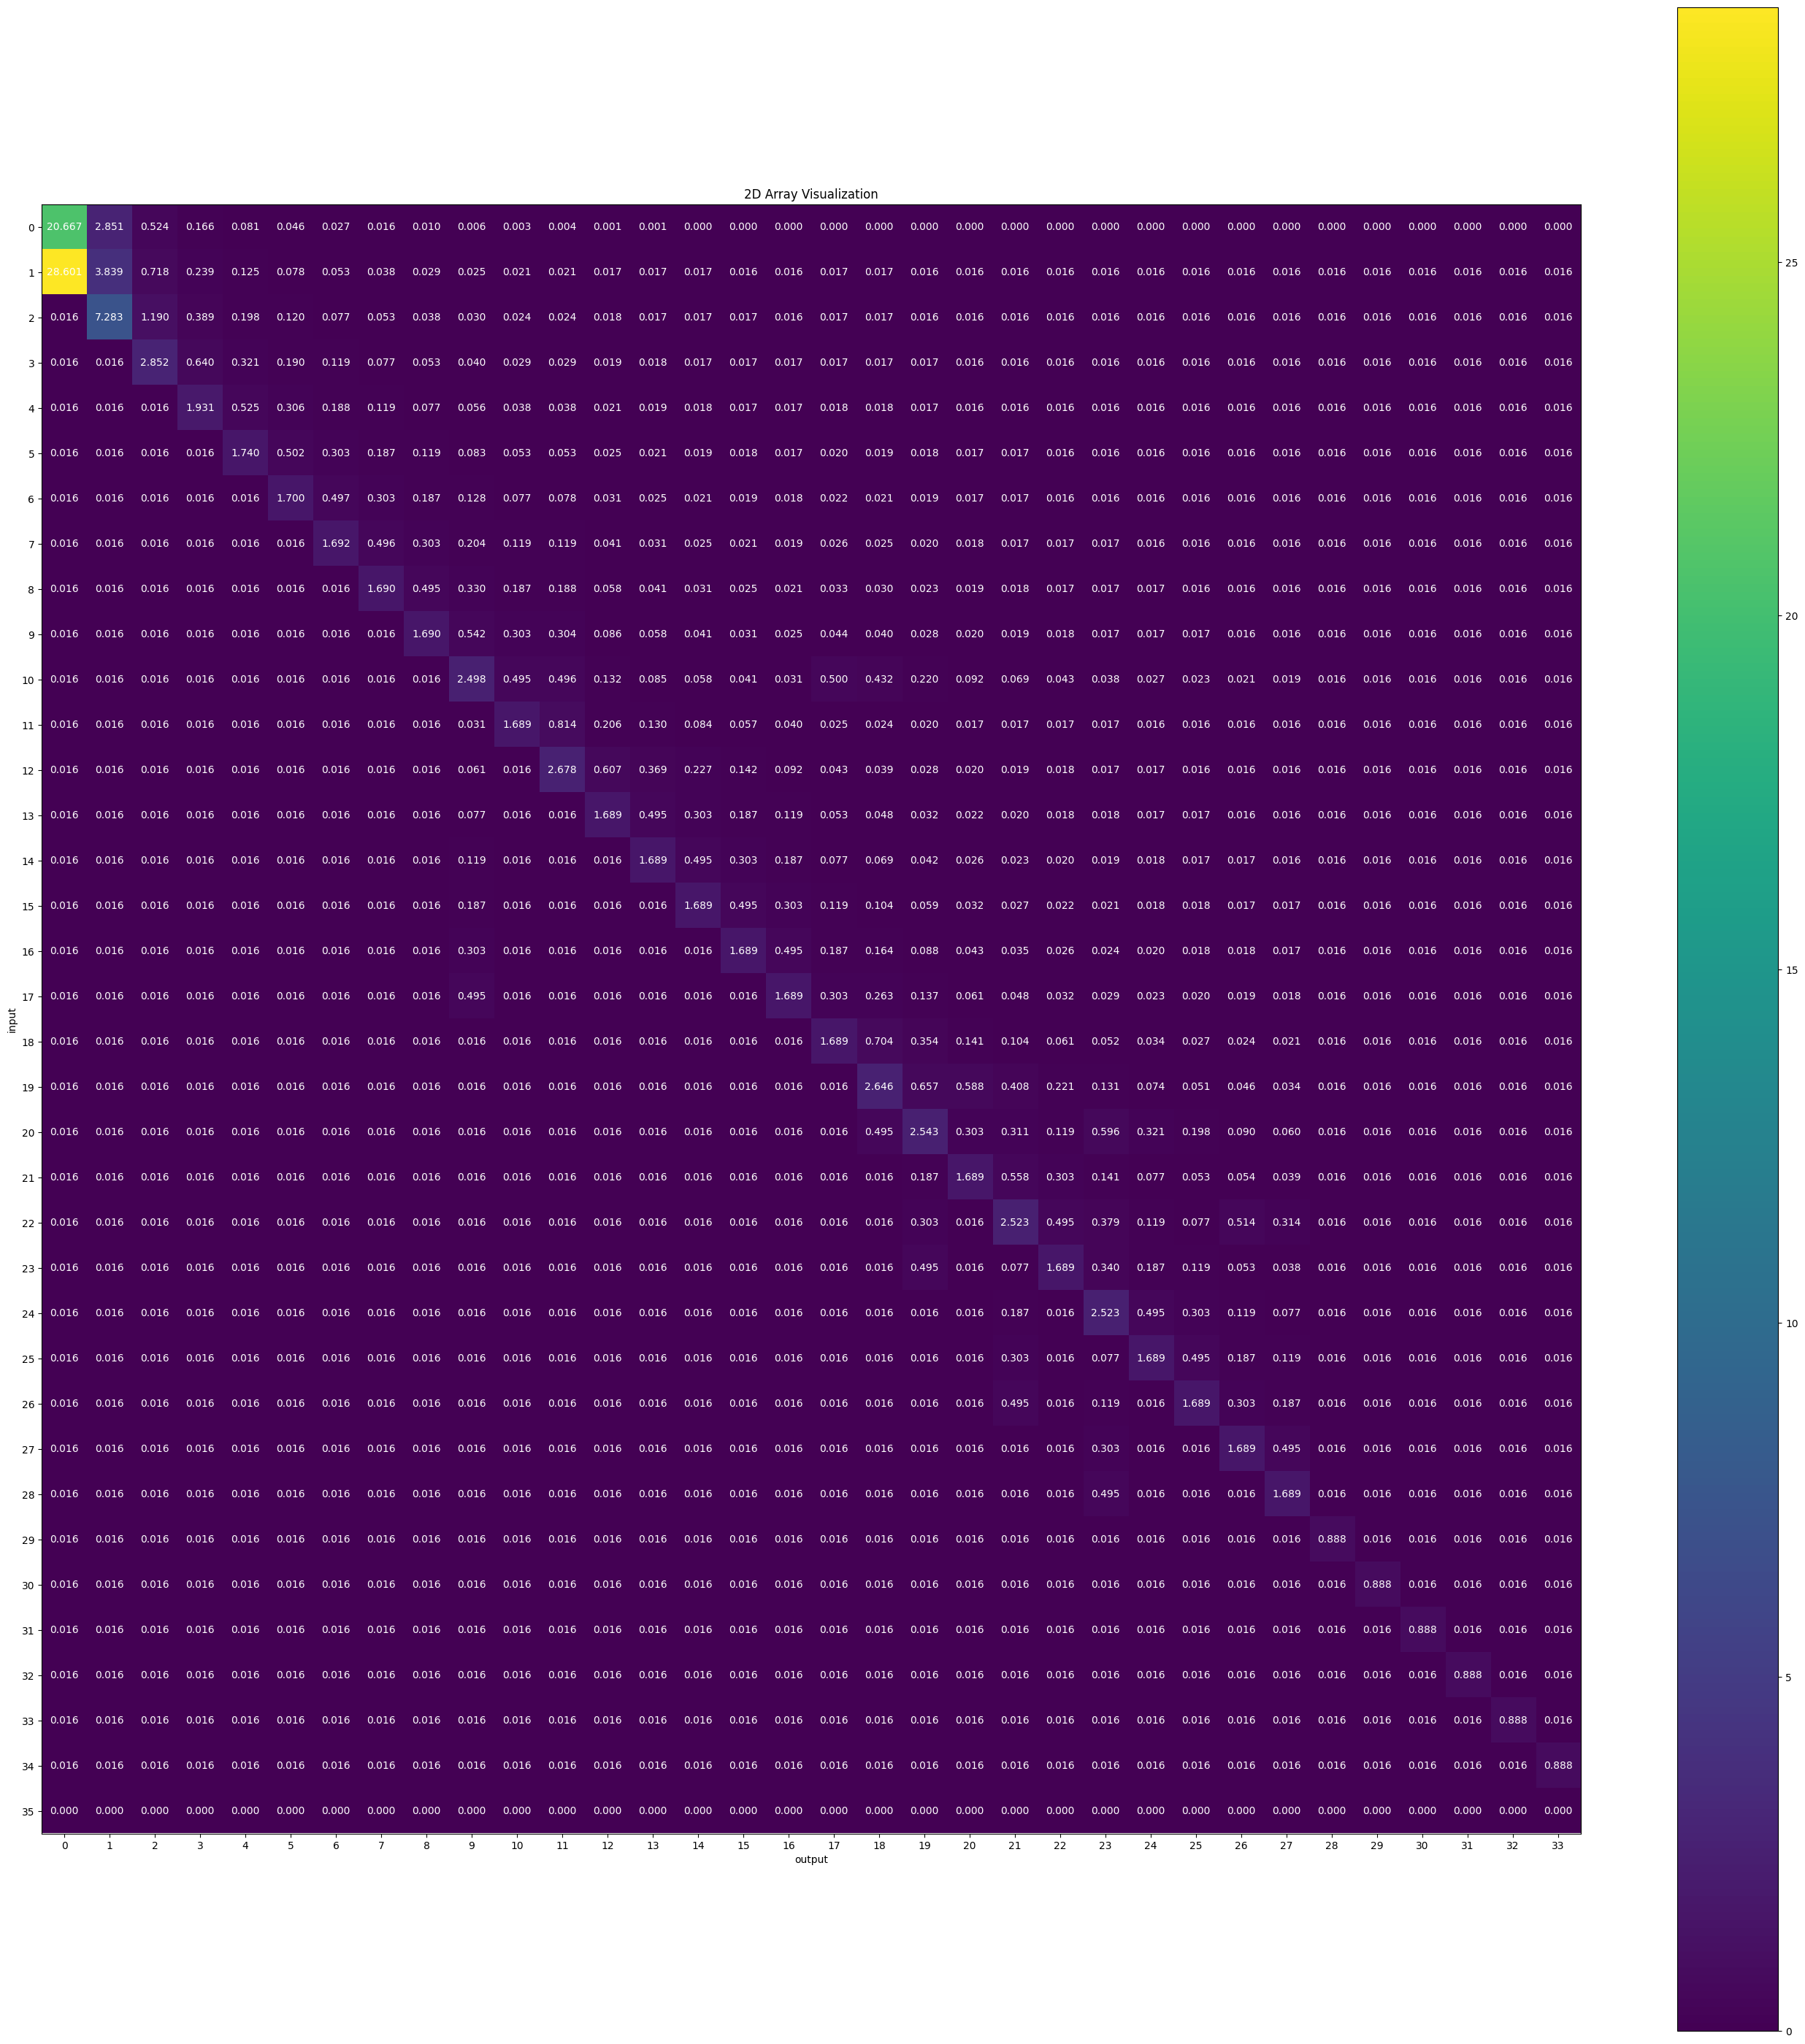

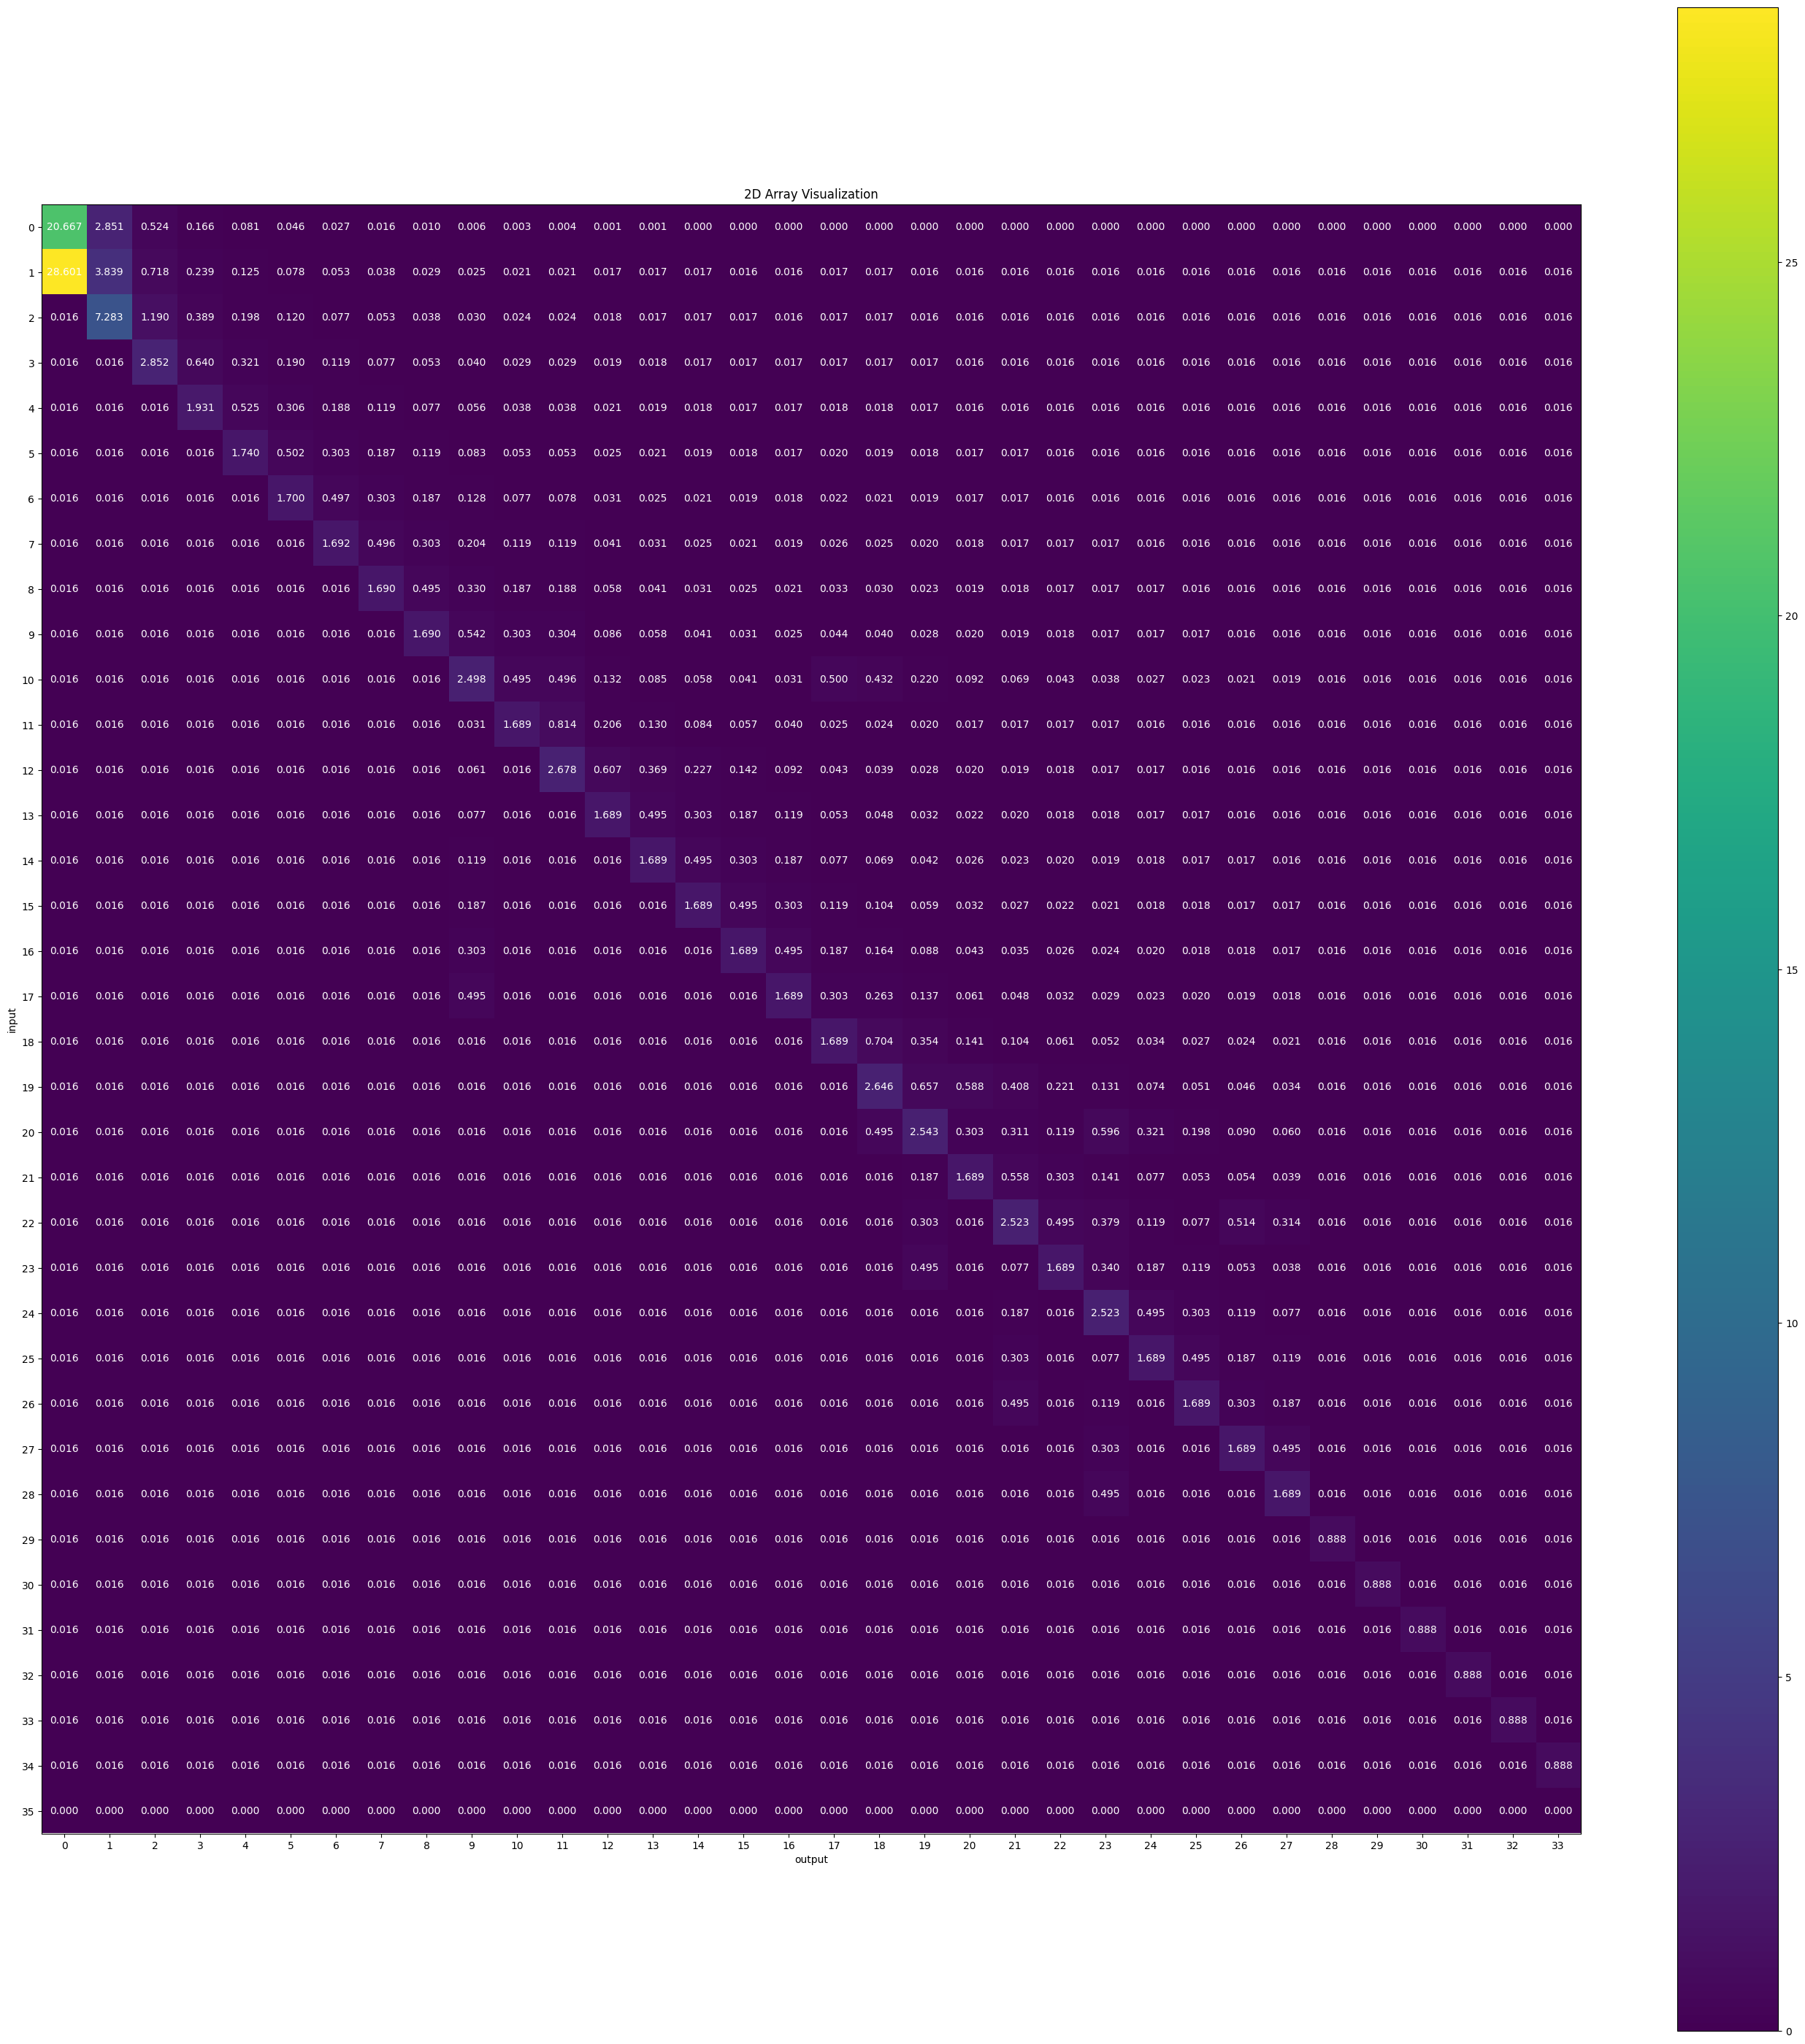

In [2]:
from compmempy.models.memorysearch import Base_CMR
from compmempy.simulation import orthonormal_activation_matrix, visualize_2d_array
from compmempy.parameters import Parameters

trial, presentation = (
    np.array([ 1,  2,  3,  4,  5,  6,  7,  9, 10, 11, 17, 14, 12, 15, 25, 20, 28,
            30, 39, 38, 37, 18,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
            0,  0,  0,  0,  0,  0]),
    np.array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 12, 13, 14, 15, 16,
            17, 10, 18, 19, 20, 19, 21, 22, 23, 20, 24, 25, 26, 22, 27, 28, 24,
            29, 30, 31, 32, 33, 34]))

full_parameters = Parameters(param_path)
parameters = full_parameters.fixed
items = np.eye(item_count)

model = Base_CMR(items, item_count, parameters)
model.experience(items[presentation[:34]-1])

print('Pre-retrieval')
print(model.context.state())
print()

print(model.outcome_probabilities())
print()

# print('Starting retrieval')
# model.start_retrieving()
# print(model.context.state())
# print()

# print(model.outcome_probabilities())
# print()

old_state = model.mcf.memory
visualize_2d_array(model.mcf.memory)
visualize_2d_array(orthonormal_activation_matrix(model.mcf))
# visualize_2d_array(orthonormal_activation_matrix(model.mfc))

In [3]:
presentation[33]

24

In [4]:
items[presentation-1].shape

(40, 34)

In [5]:
items[presentation[33:34]-1]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]])

In [6]:
items[presentation[34:35]-1]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0.]])

Pre-retrieval
[1.03951257e-07 1.39391660e-07 2.33167799e-07 3.90031933e-07
 6.52425951e-07 1.09134184e-06 1.82551849e-06 3.05351500e-06
 5.10718323e-06 8.54028424e-06 1.48723069e-04 2.68174973e-06
 8.33334190e-06 1.13017248e-05 1.89042178e-05 3.16184446e-05
 5.28727923e-05 8.83633676e-05 2.44903543e-04 8.61528043e-04
 3.18584244e-03 1.01087713e-03 8.73821246e-03 1.71320521e-03
 3.80492241e-02 2.79398729e-03 4.67365137e-03 1.30773602e-02
 2.18751971e-02 6.12090655e-02 1.02387664e-01 1.71269300e-01
 2.86491282e-01 4.79229228e-01 8.01632258e-01 0.00000000e+00]

[0.003449   0.01049596 0.01049479 0.01049446 0.01049449 0.01049475
 0.01049523 0.01049607 0.01049749 0.01049986 0.01063792 0.01051988
 0.01052639 0.0105078  0.01051062 0.01051794 0.01053174 0.01055573
 0.01066378 0.01181517 0.01447624 0.01151814 0.02137846 0.01305463
 0.04829294 0.01869623 0.01746997 0.02101679 0.02648533 0.02786827
 0.0395569  0.05910908 0.09181506 0.14652409 0.23803879]



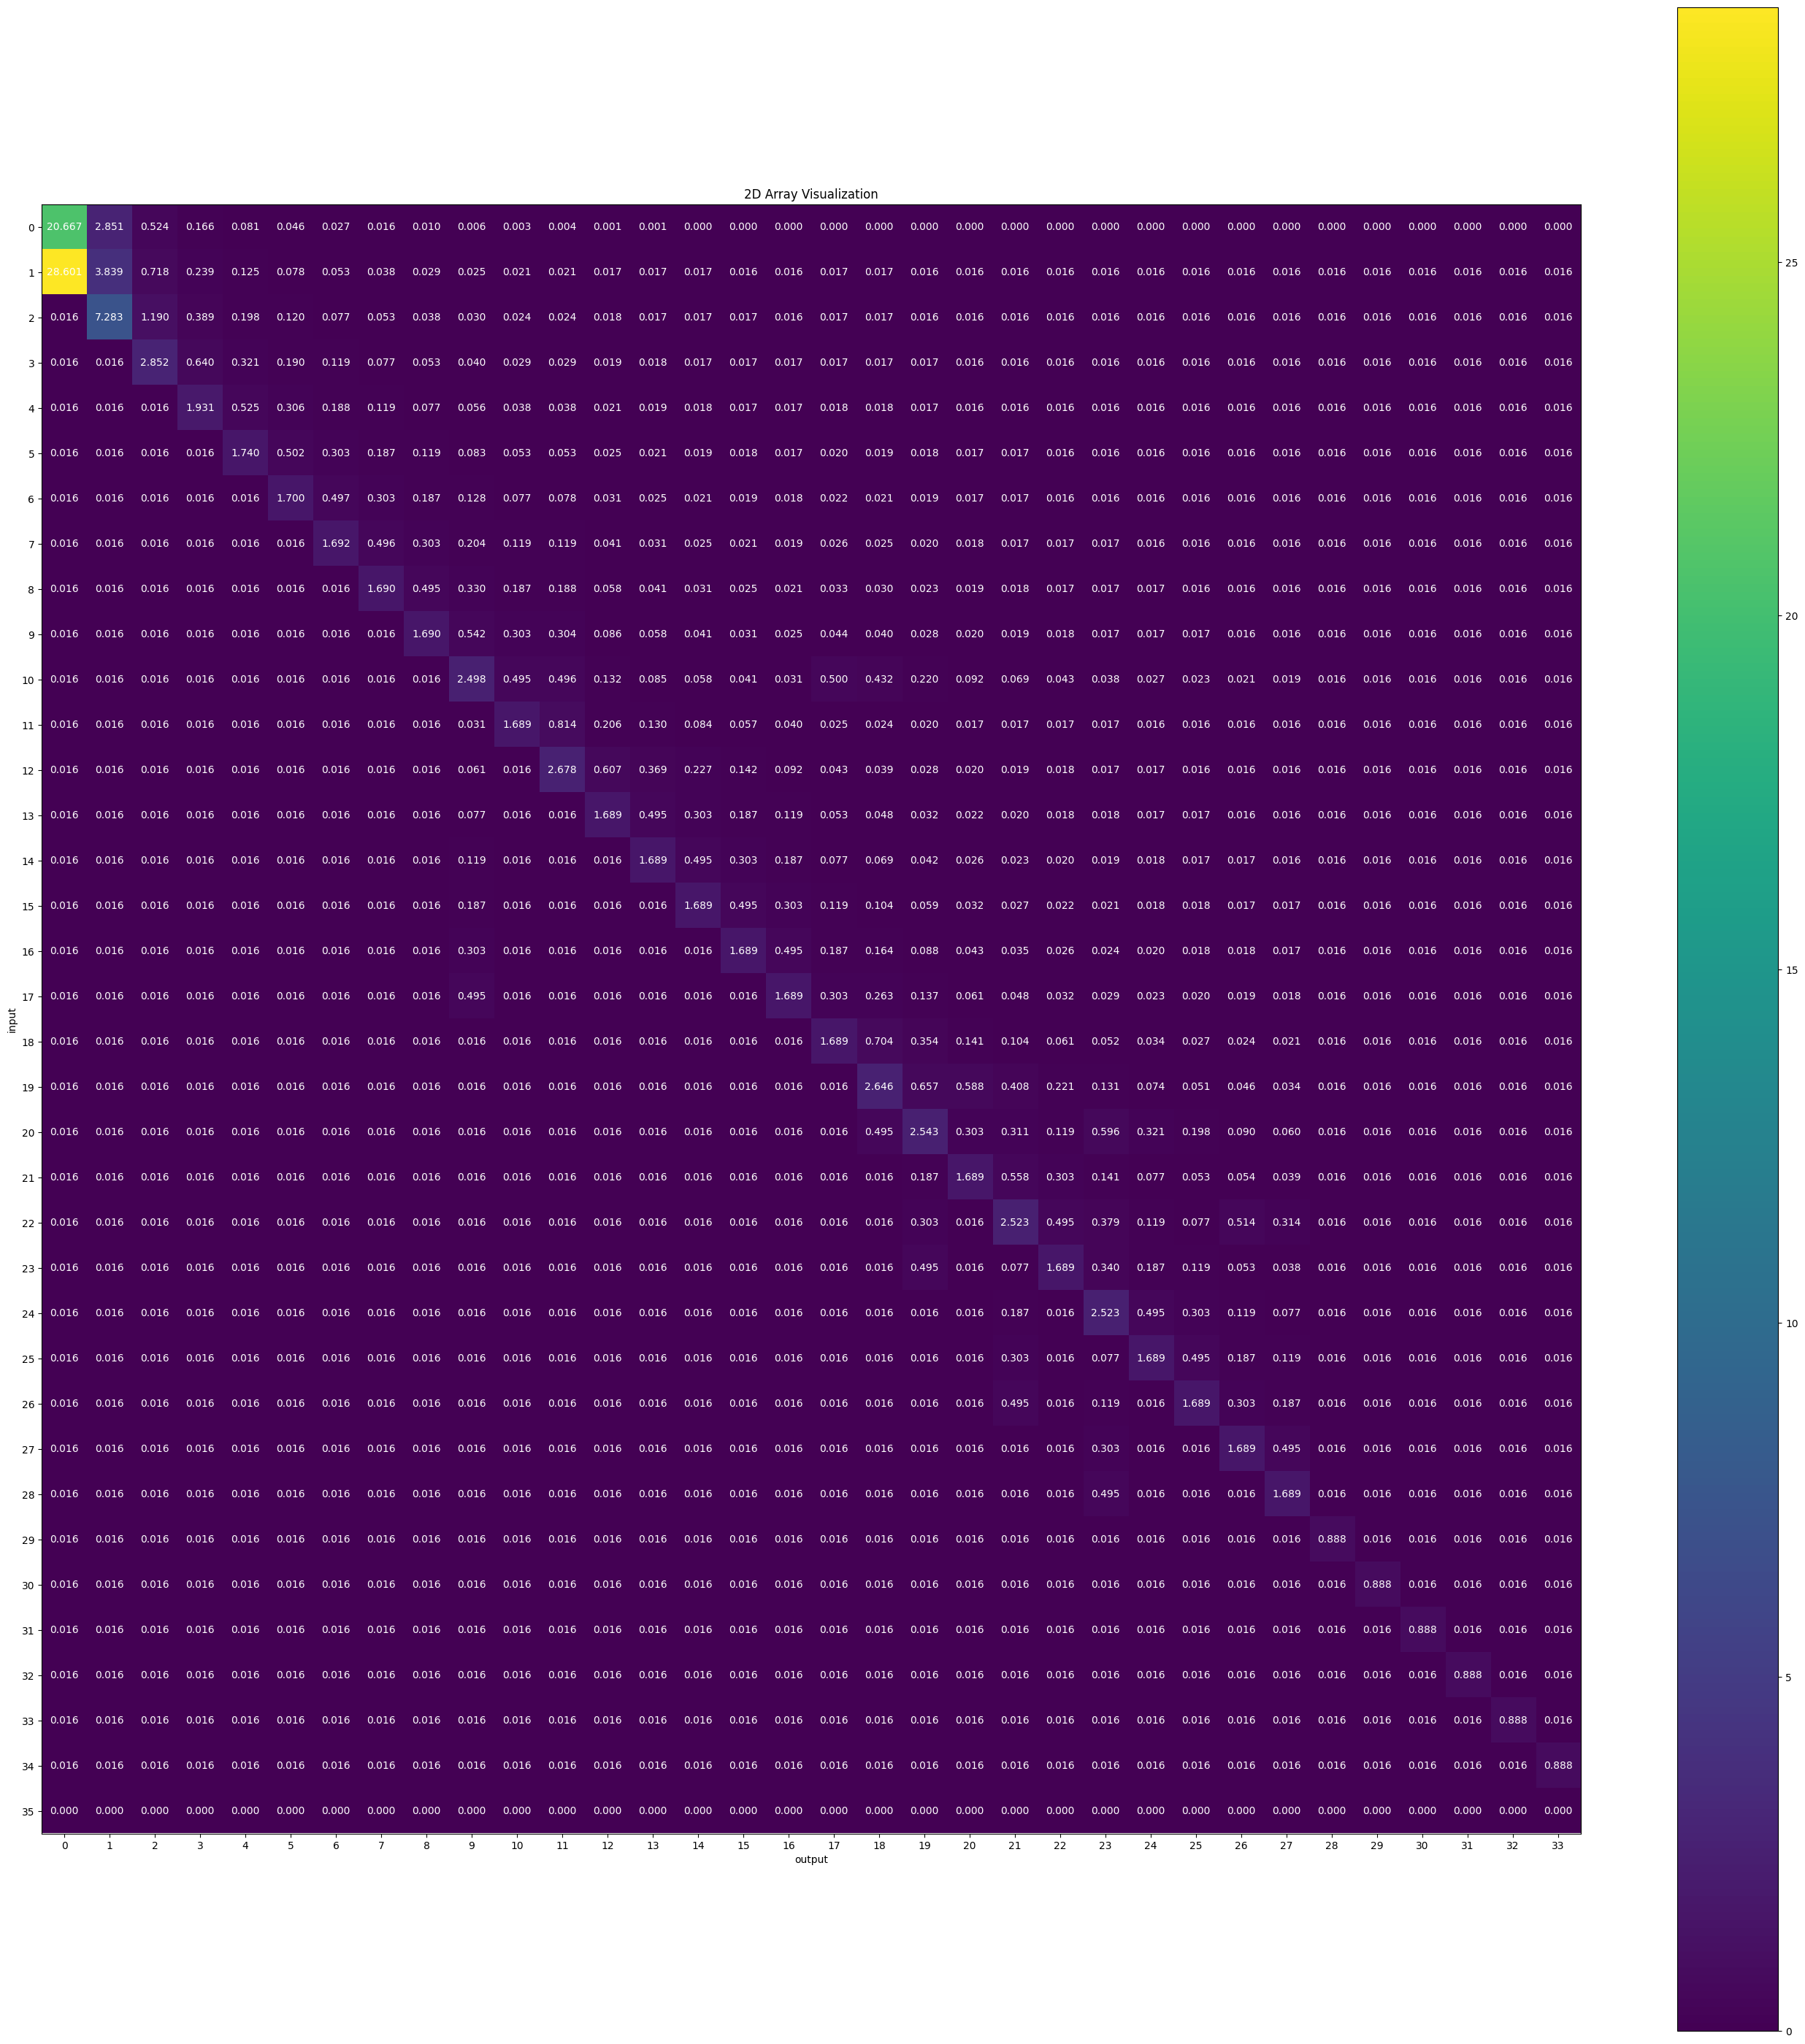

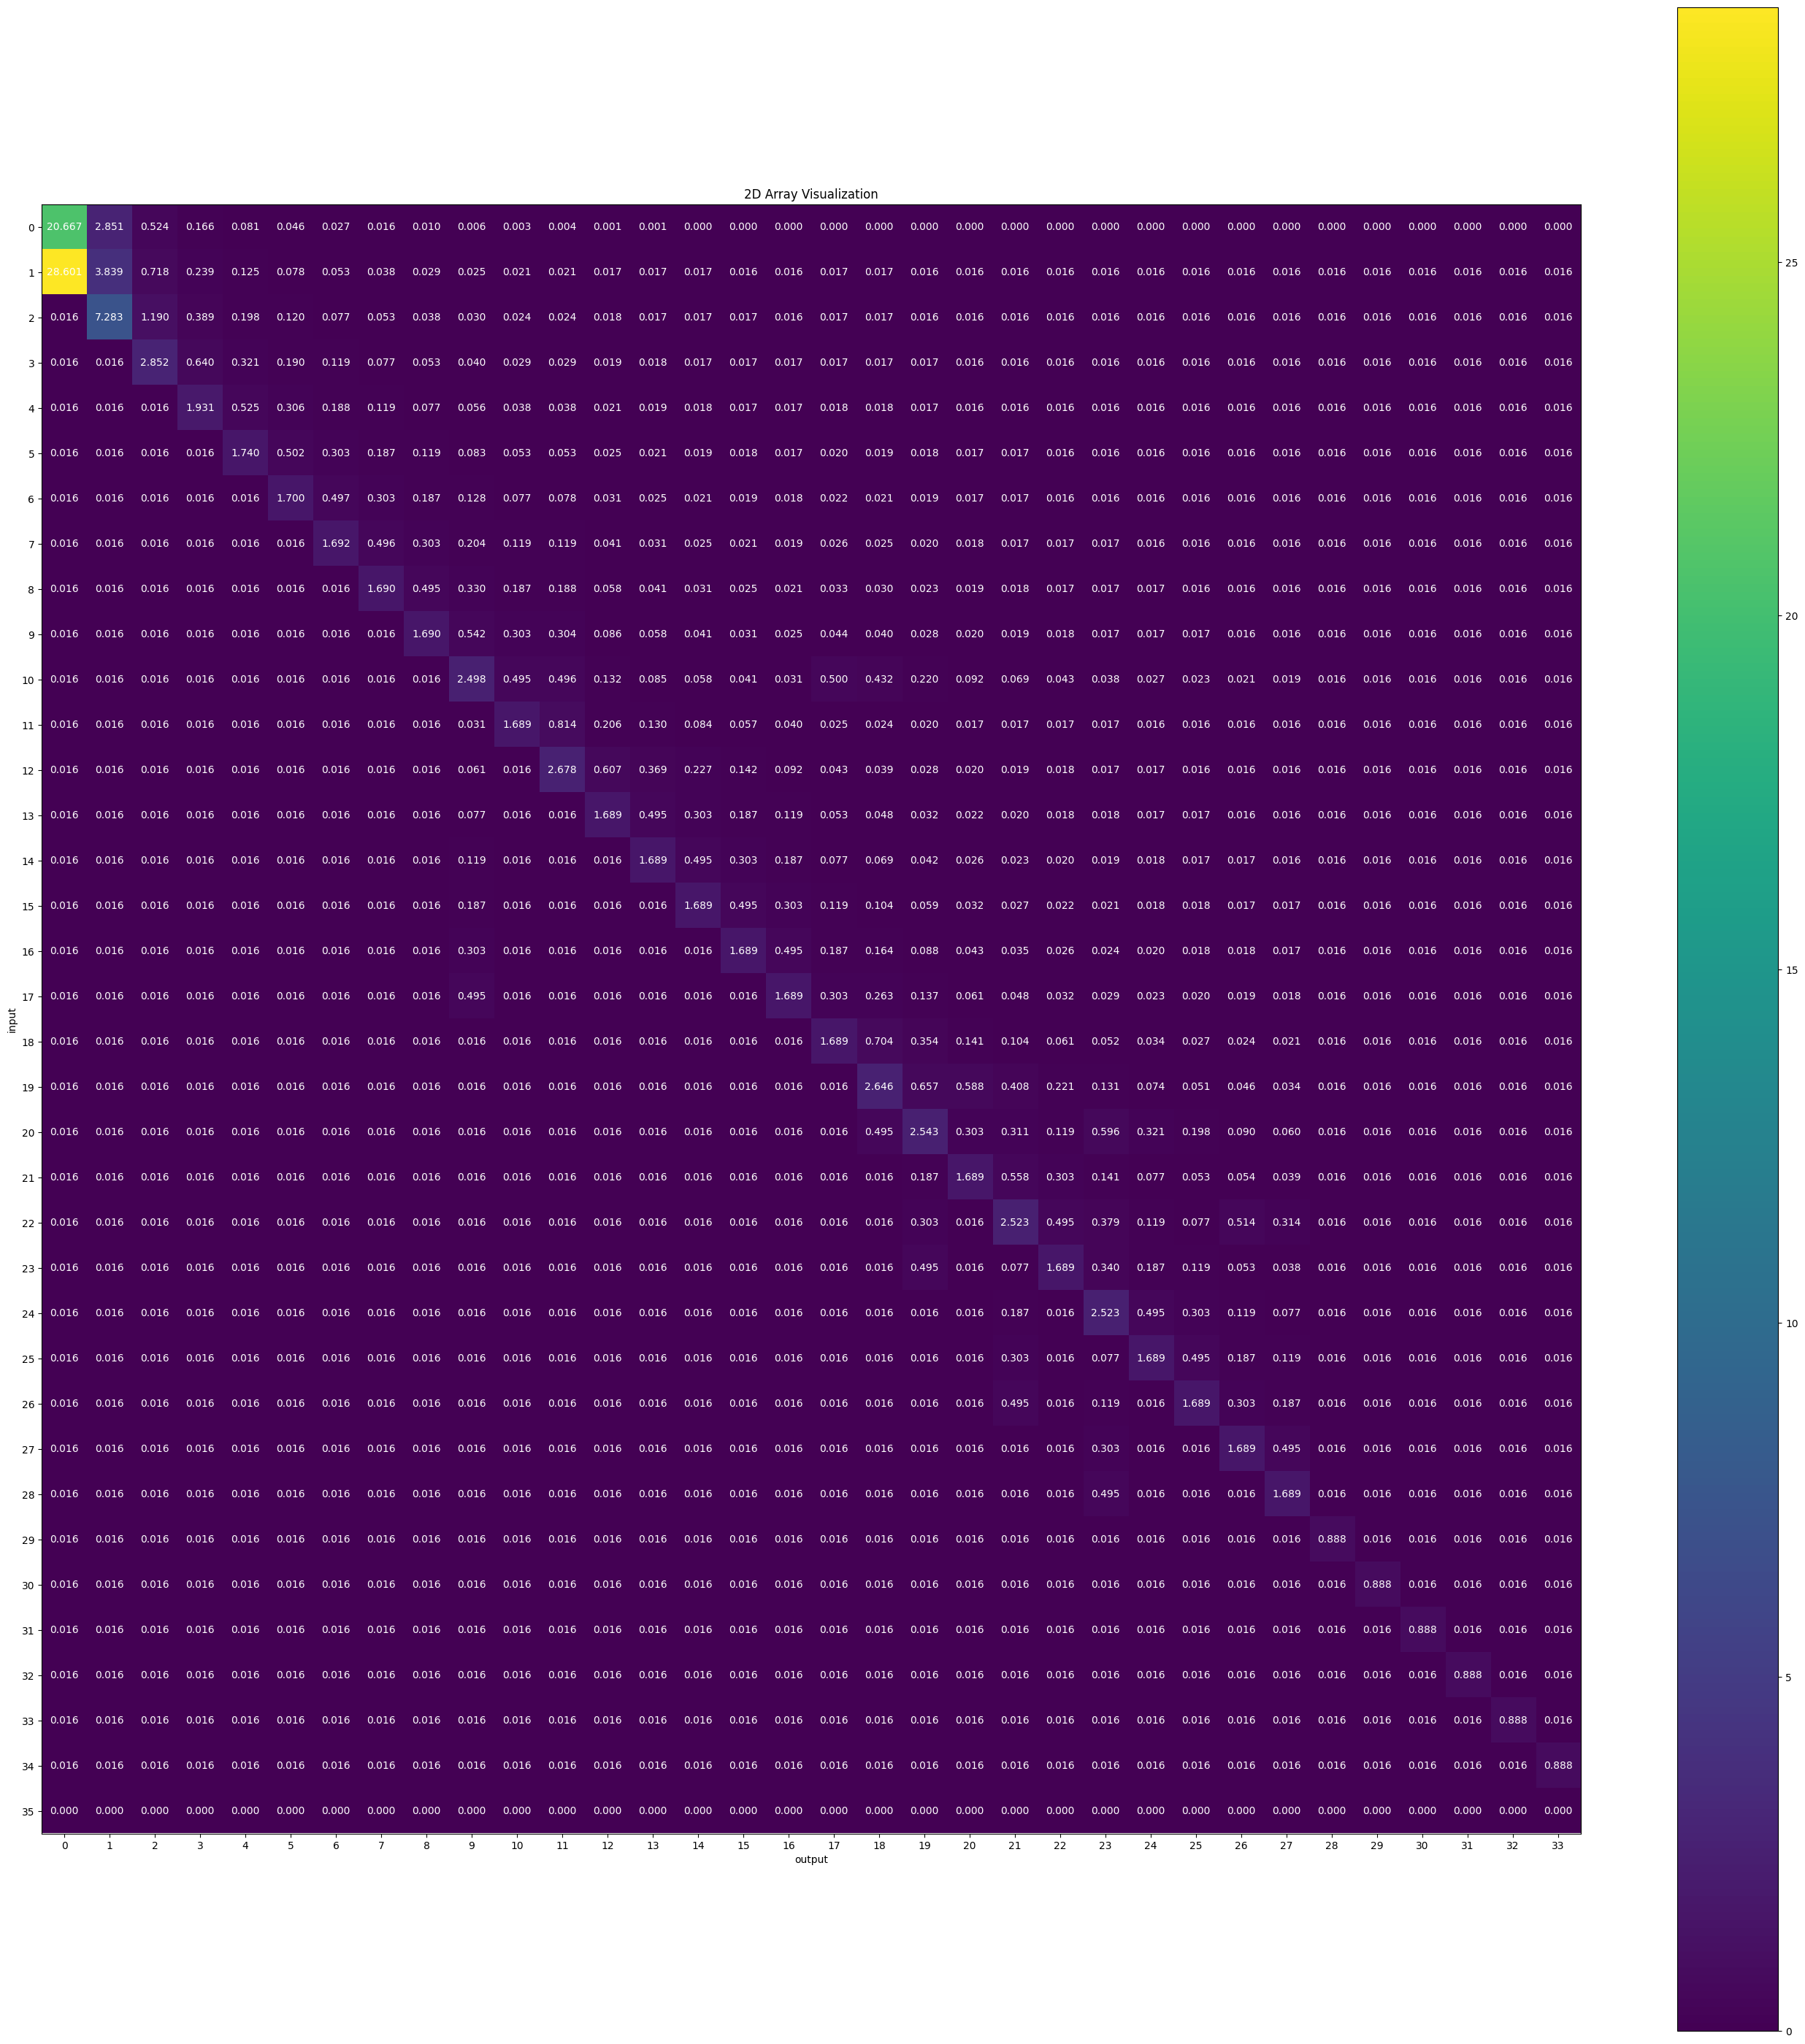

True

In [7]:
full_parameters = Parameters(param_path)
parameters = full_parameters.fixed

trial, presentation = (
    np.array([ 1,  2,  3,  4,  5,  6,  7,  9, 10, 11, 17, 14, 12, 15, 25, 20, 28,
            30, 39, 38, 37, 18,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
            0,  0,  0,  0,  0,  0]),
    np.array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 12, 13, 14, 15, 16,
            17, 10, 18, 19, 20, 19, 21, 22, 23, 20, 24, 25, 26, 22, 27, 28, 24,
            29, 30, 31, 32, 33, 34]))

model = Base_CMR(items, item_count, parameters)
model.experience(items[presentation-1])

print('Pre-retrieval')
print(model.context.state())
print()

print(model.outcome_probabilities())
print()

# print('Starting retrieval')
# model.start_retrieving()
# print(model.context.state())
# print()

# print(model.outcome_probabilities())
# print()

visualize_2d_array(model.mcf.memory)
visualize_2d_array(orthonormal_activation_matrix(model.mcf))
np.allclose(old_state, model.mcf.memory)

## Jax Implementation

Pre-retrieval
[2.27730654e-06 3.05371717e-06 5.10811414e-06 8.54460883e-06
 1.42929952e-05 2.39085274e-05 3.99924726e-05 6.68947567e-05
 1.11885410e-04 1.87095932e-04 3.25814291e-03 5.87503001e-05
 1.82562231e-04 2.47591978e-04 4.14143215e-04 6.92679510e-04
 1.15830808e-03 1.93581610e-03 5.36521216e-03 1.88738773e-02
 6.97936603e-02 2.21457363e-02 1.91431835e-01 3.75319486e-02
 8.33560936e-01 6.12091036e-02 1.02387728e-01 2.86491460e-01
 4.79229527e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]

[0.003449   0.00433513 0.00432512 0.00432237 0.00432264 0.00432477
 0.00432893 0.0043361  0.00434814 0.00436831 0.00554373 0.00453872
 0.00459418 0.00443595 0.00445994 0.00452227 0.00463977 0.00484395
 0.00576392 0.01556652 0.03822203 0.01303768 0.09698554 0.02611893
 0.32612757 0.07414984 0.06370979 0.09390637 0.14046398 0.00431813
 0.00431813 0.00431813 0.00431813 0.00431813 0.00431813]



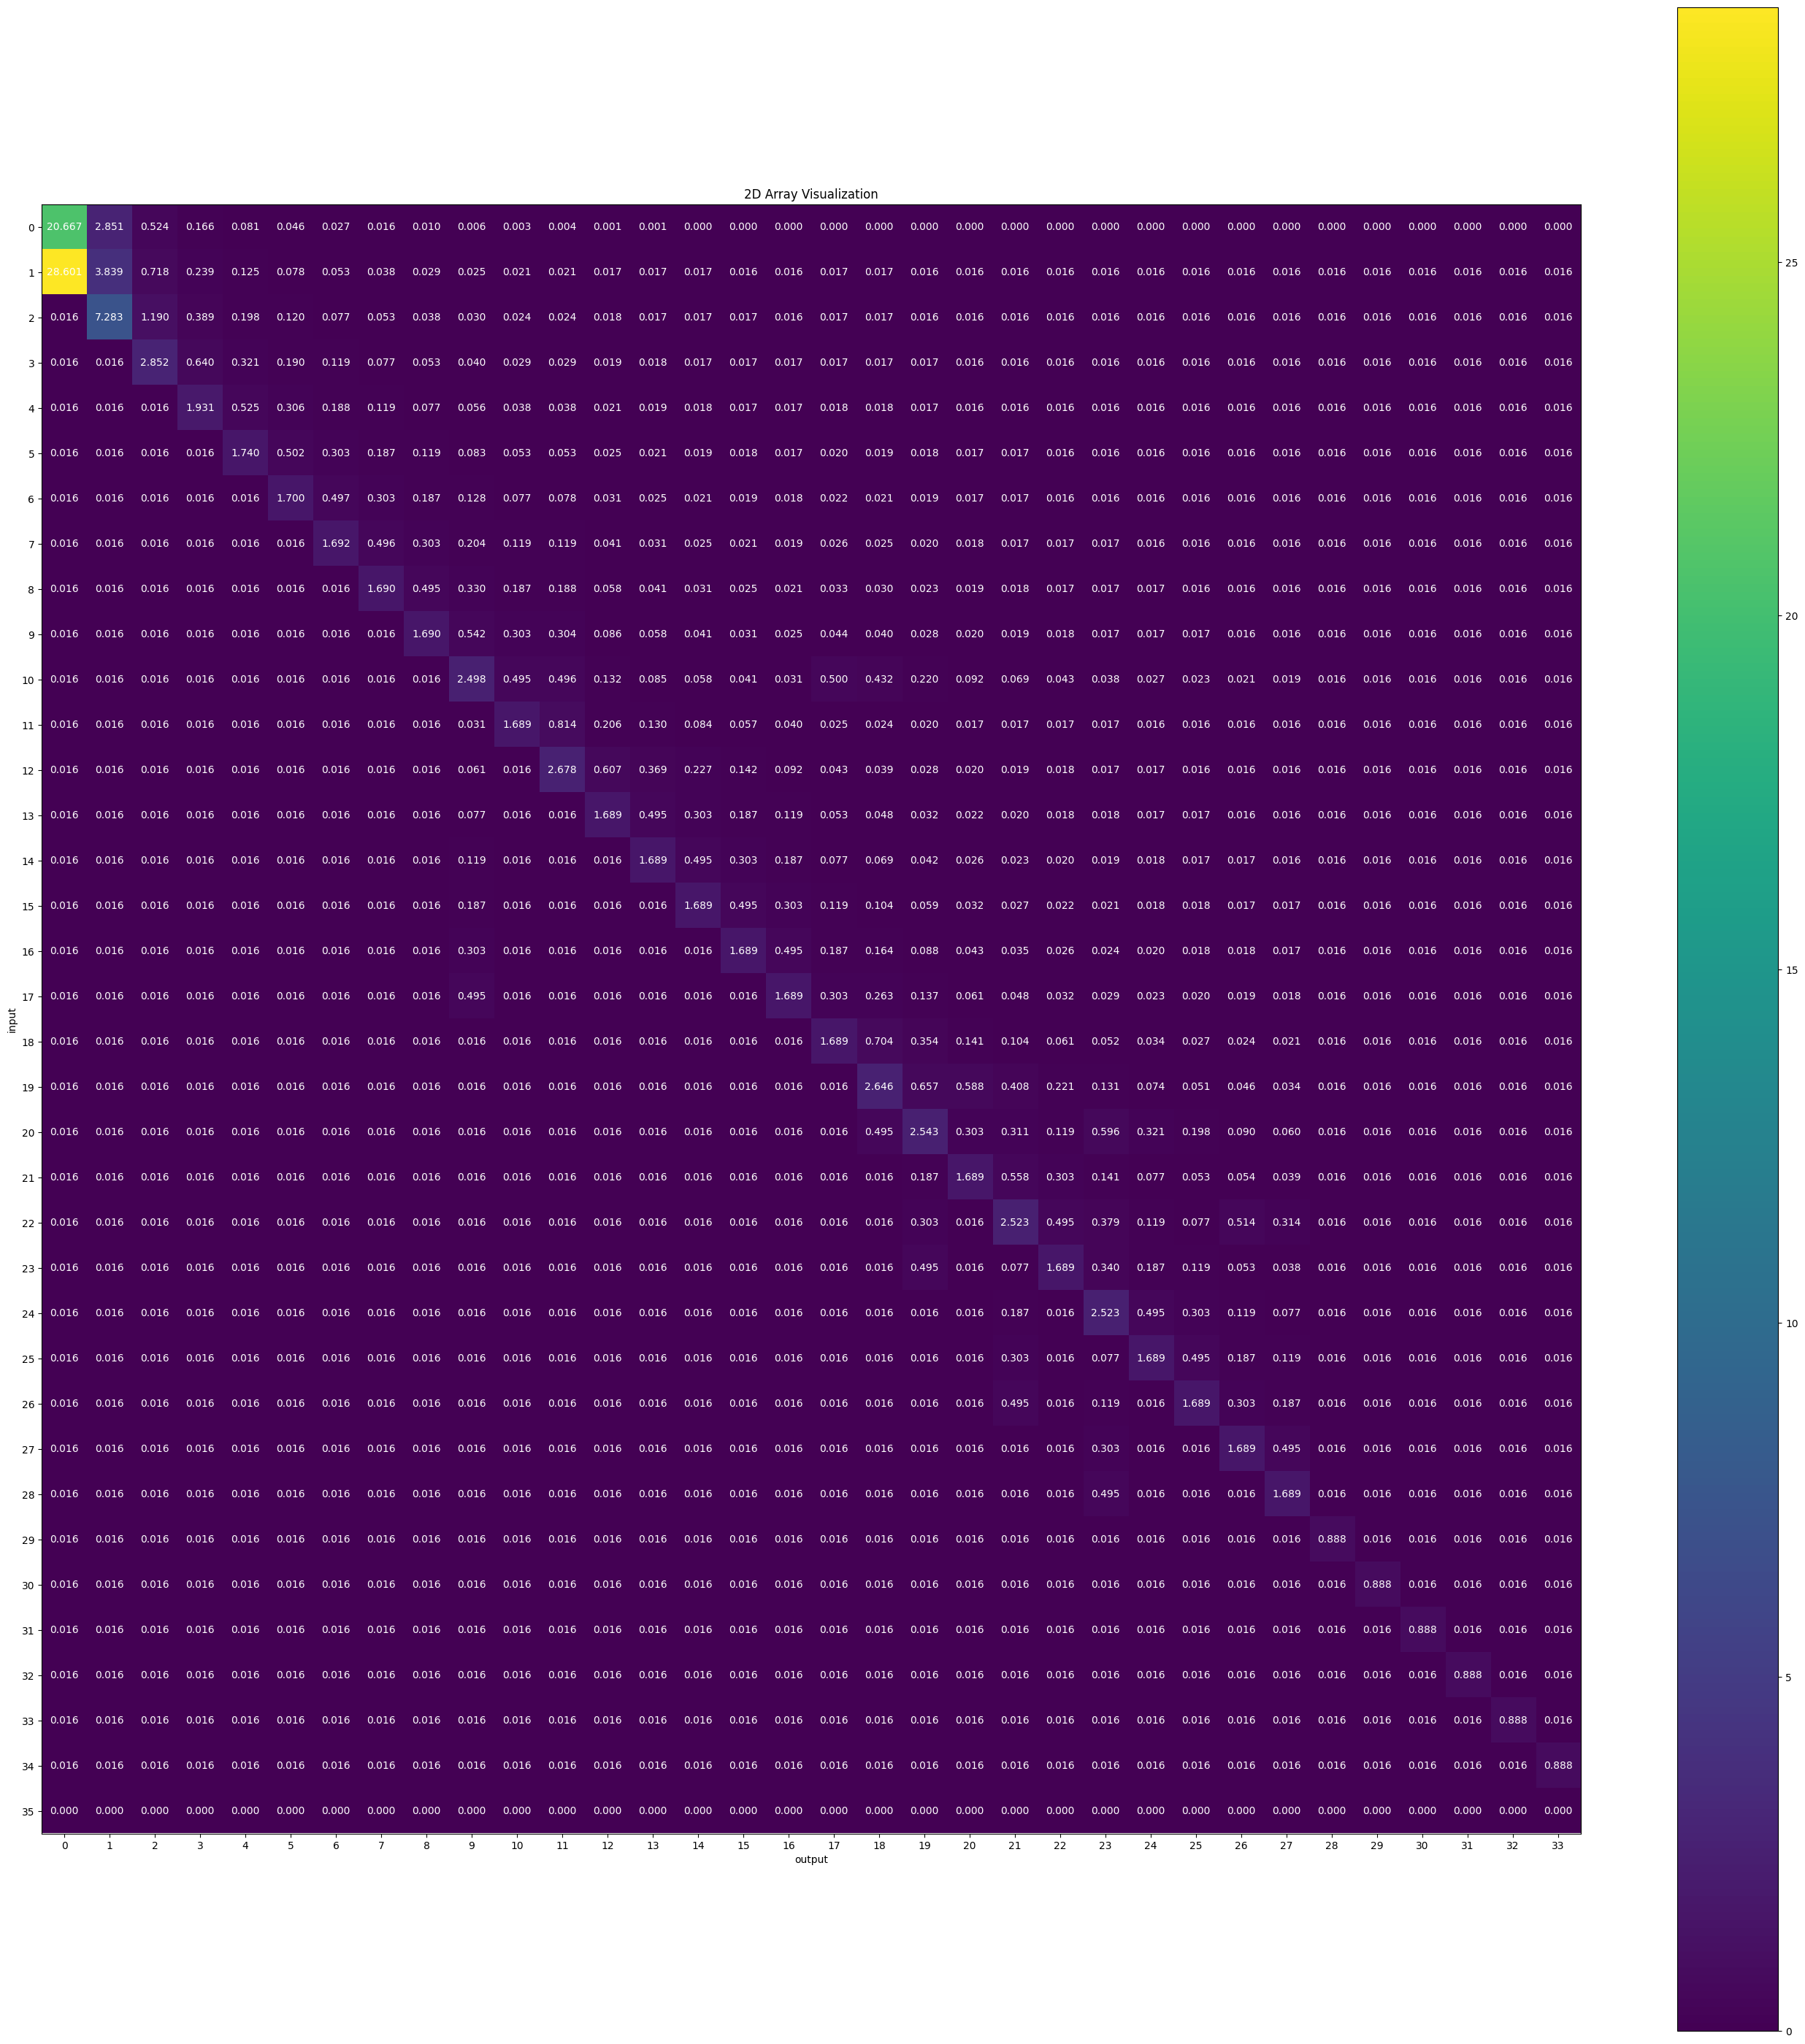

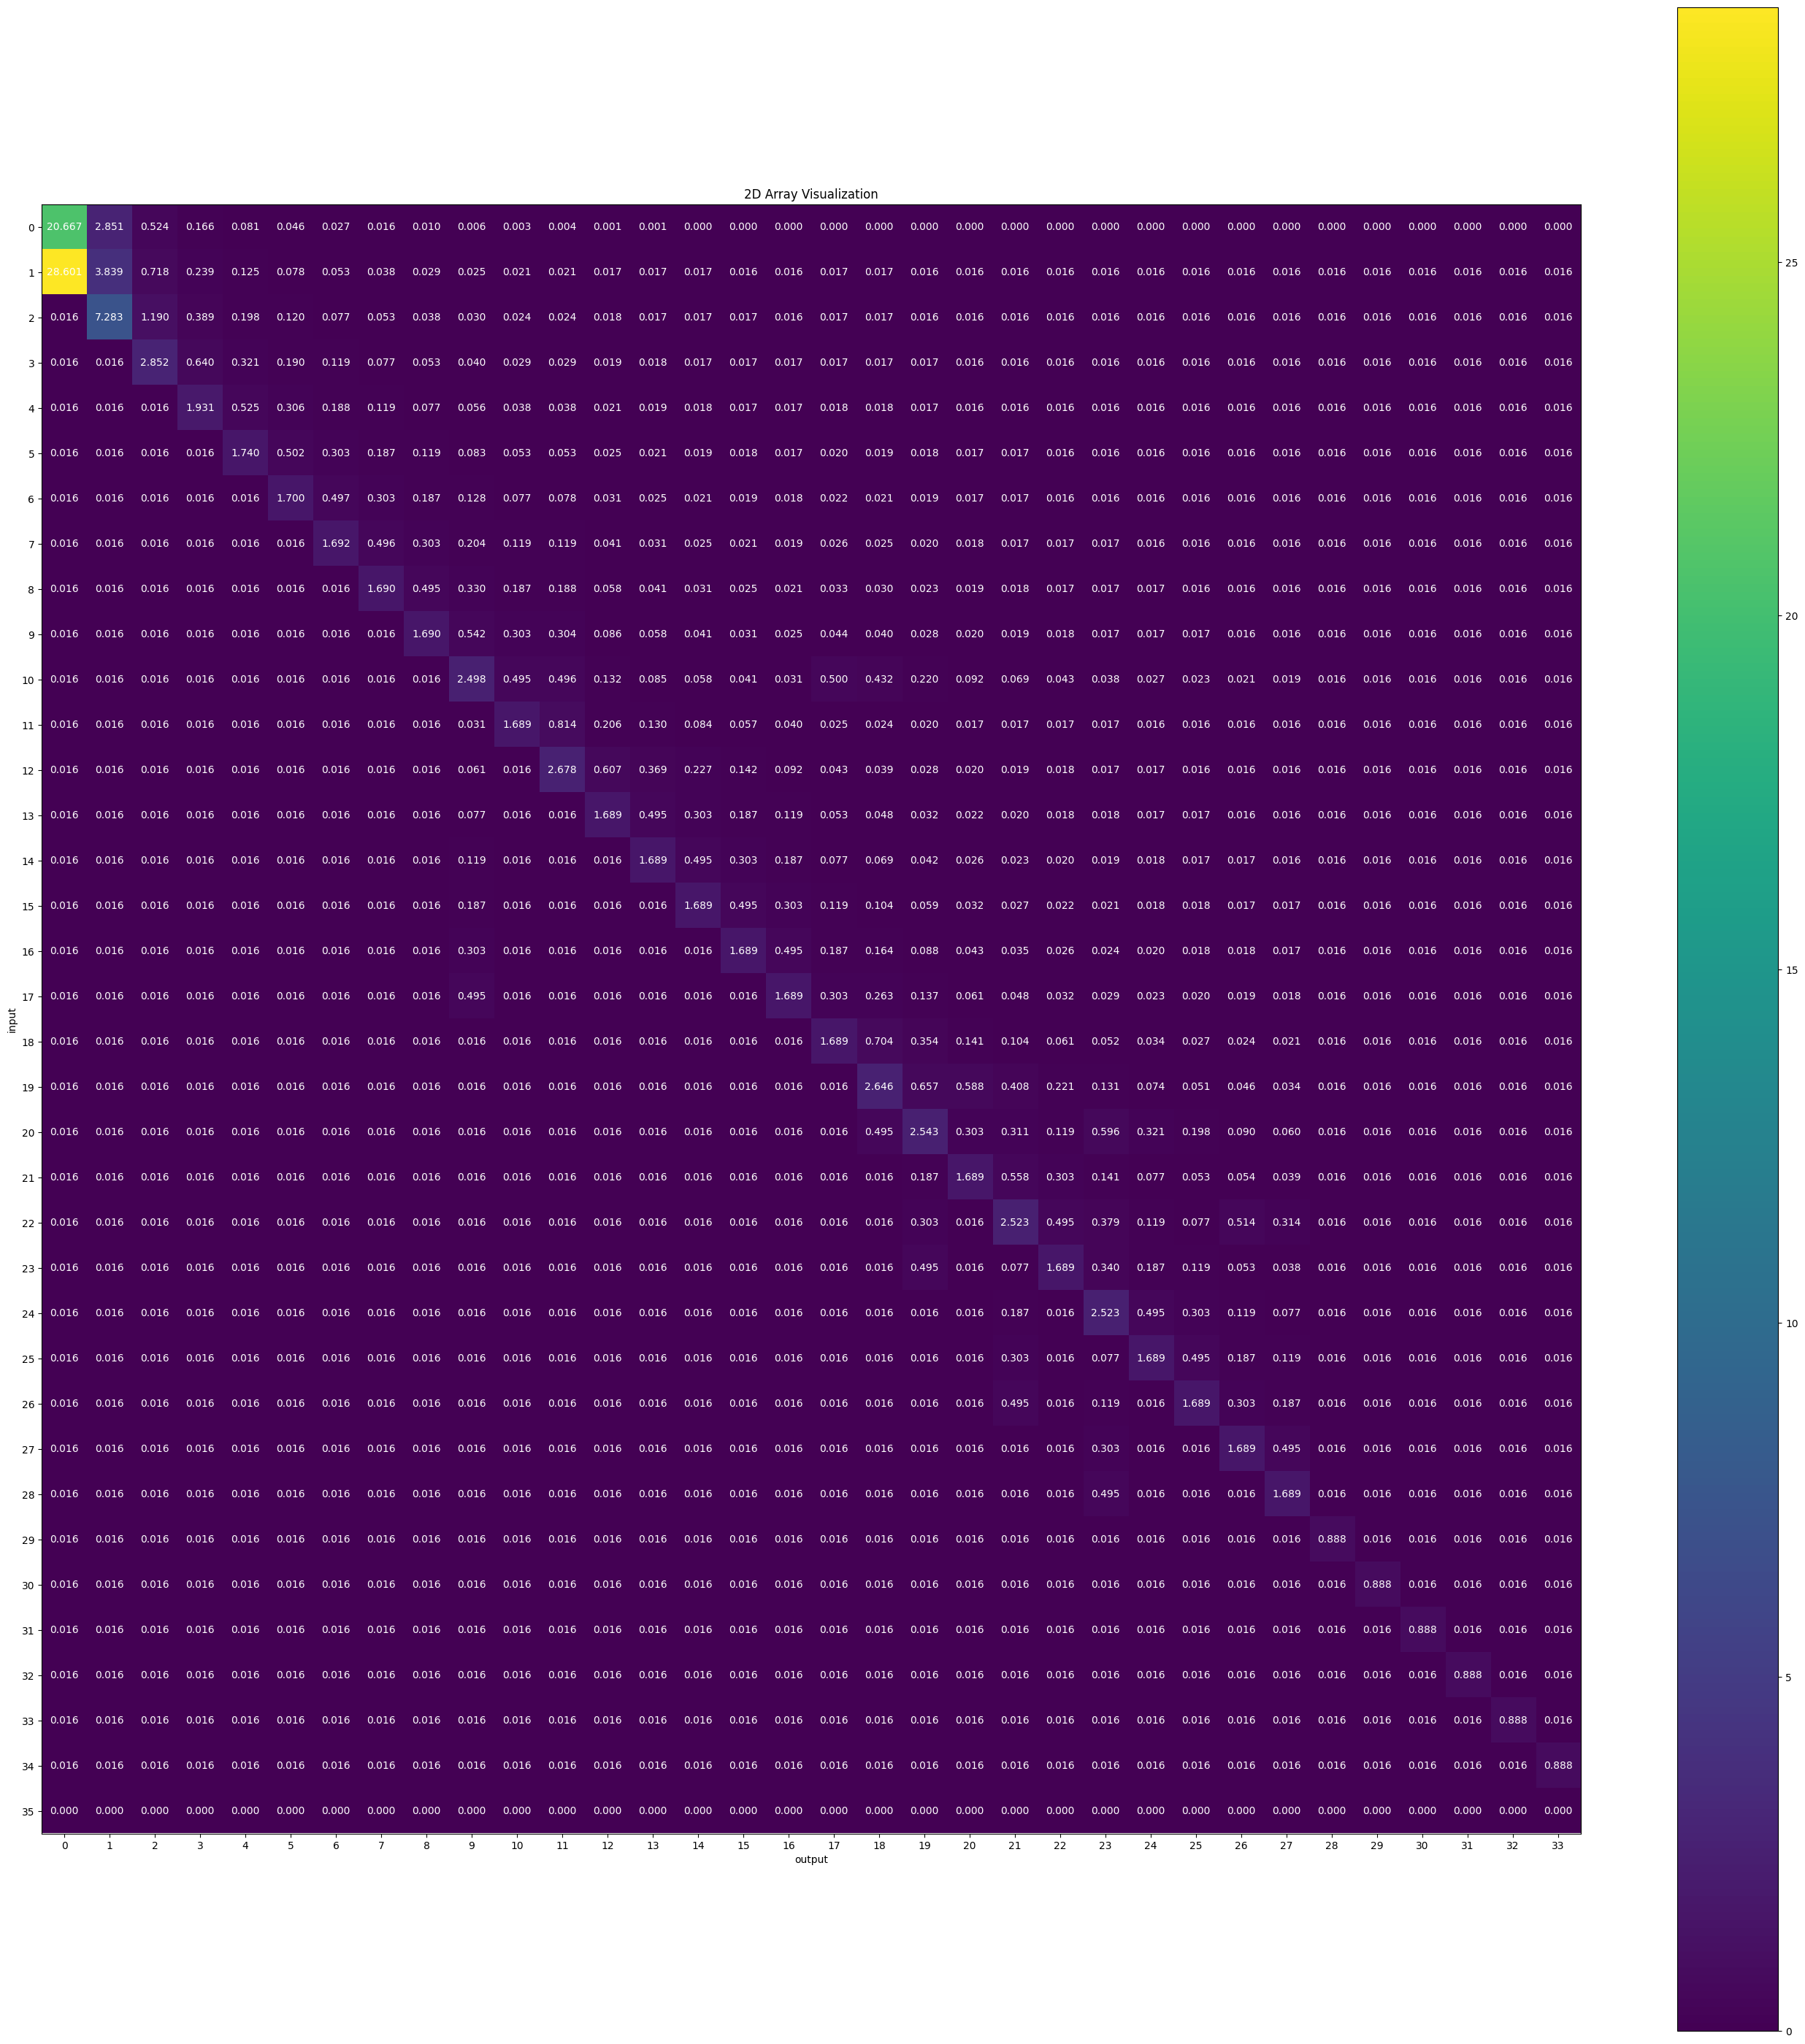

In [13]:
from jaxcmr.memorysearch import BaseCMR, experience, outcome_probabilities, start_retrieving, retrieve

from jax import lax, numpy as jnp, config
from jaxcmr.memory import probe
import json
import jax
config.update('jax_enable_x64', True)

with open(param_path) as f:
    full_parameters = json.load(f)
parameters = full_parameters['fixed']

jax_model = BaseCMR.create(item_count, list_length, parameters)

# with jax.disable_jit():
jax_model = experience(jax_model, jnp.array(presentation)[:34])

print('Pre-retrieval')
print(jax_model.context.state)
print()

# with jax.disable_jit():
print(outcome_probabilities(jax_model))
print()

# print('Starting retrieval')
# jax_model = start_retrieving(jax_model)
# print(jax_model.context.state)
# print()

# print(outcome_probabilities(jax_model))
# print()

activation_matrix = lax.map(
    lambda _probe: probe(jax_model.mcf, _probe), 
    np.eye(jax_model.mcf.state.shape[0])
    )

visualize_2d_array(jax_model.mcf.state)
visualize_2d_array(activation_matrix)

# orthonormal_activation_matrix = lax.map(
#     lambda _probe: probe(jax_model.mfc, _probe), 
#     np.eye(jax_model.mfc.state.shape[0])
#     )

# # visualize_2d_array(jax_model.mfc.state)
# visualize_2d_array(orthonormal_activation_matrix)

Pre-retrieval
[1.03951359e-07 1.39391884e-07 2.33168173e-07 3.90032559e-07
 6.52426998e-07 1.09134359e-06 1.82552142e-06 3.05351990e-06
 5.10719143e-06 8.54029795e-06 1.48723229e-04 2.68175294e-06
 8.33334976e-06 1.13017383e-05 1.89042402e-05 3.16184822e-05
 5.28728551e-05 8.83634724e-05 2.44903830e-04 8.61528809e-04
 3.18584507e-03 1.01087813e-03 8.73821727e-03 1.71320680e-03
 3.80492438e-02 2.79398903e-03 4.67365428e-03 1.30773684e-02
 2.18752107e-02 6.12091036e-02 1.02387728e-01 1.71269407e-01
 2.86491460e-01 4.79229527e-01 8.01632758e-01 0.00000000e+00]

[0.003449   0.00590732 0.00590666 0.00590648 0.00590649 0.00590664
 0.00590691 0.00590738 0.00590818 0.00590951 0.00598722 0.00592078
 0.00592445 0.00591399 0.00591557 0.00591969 0.00592746 0.00594096
 0.00600177 0.0066498  0.00814749 0.00648262 0.01203219 0.00734739
 0.02718016 0.01052258 0.00983242 0.01182864 0.01490644 0.03000223
 0.04586556 0.0725407  0.11724515 0.19207458 0.3172756 ]



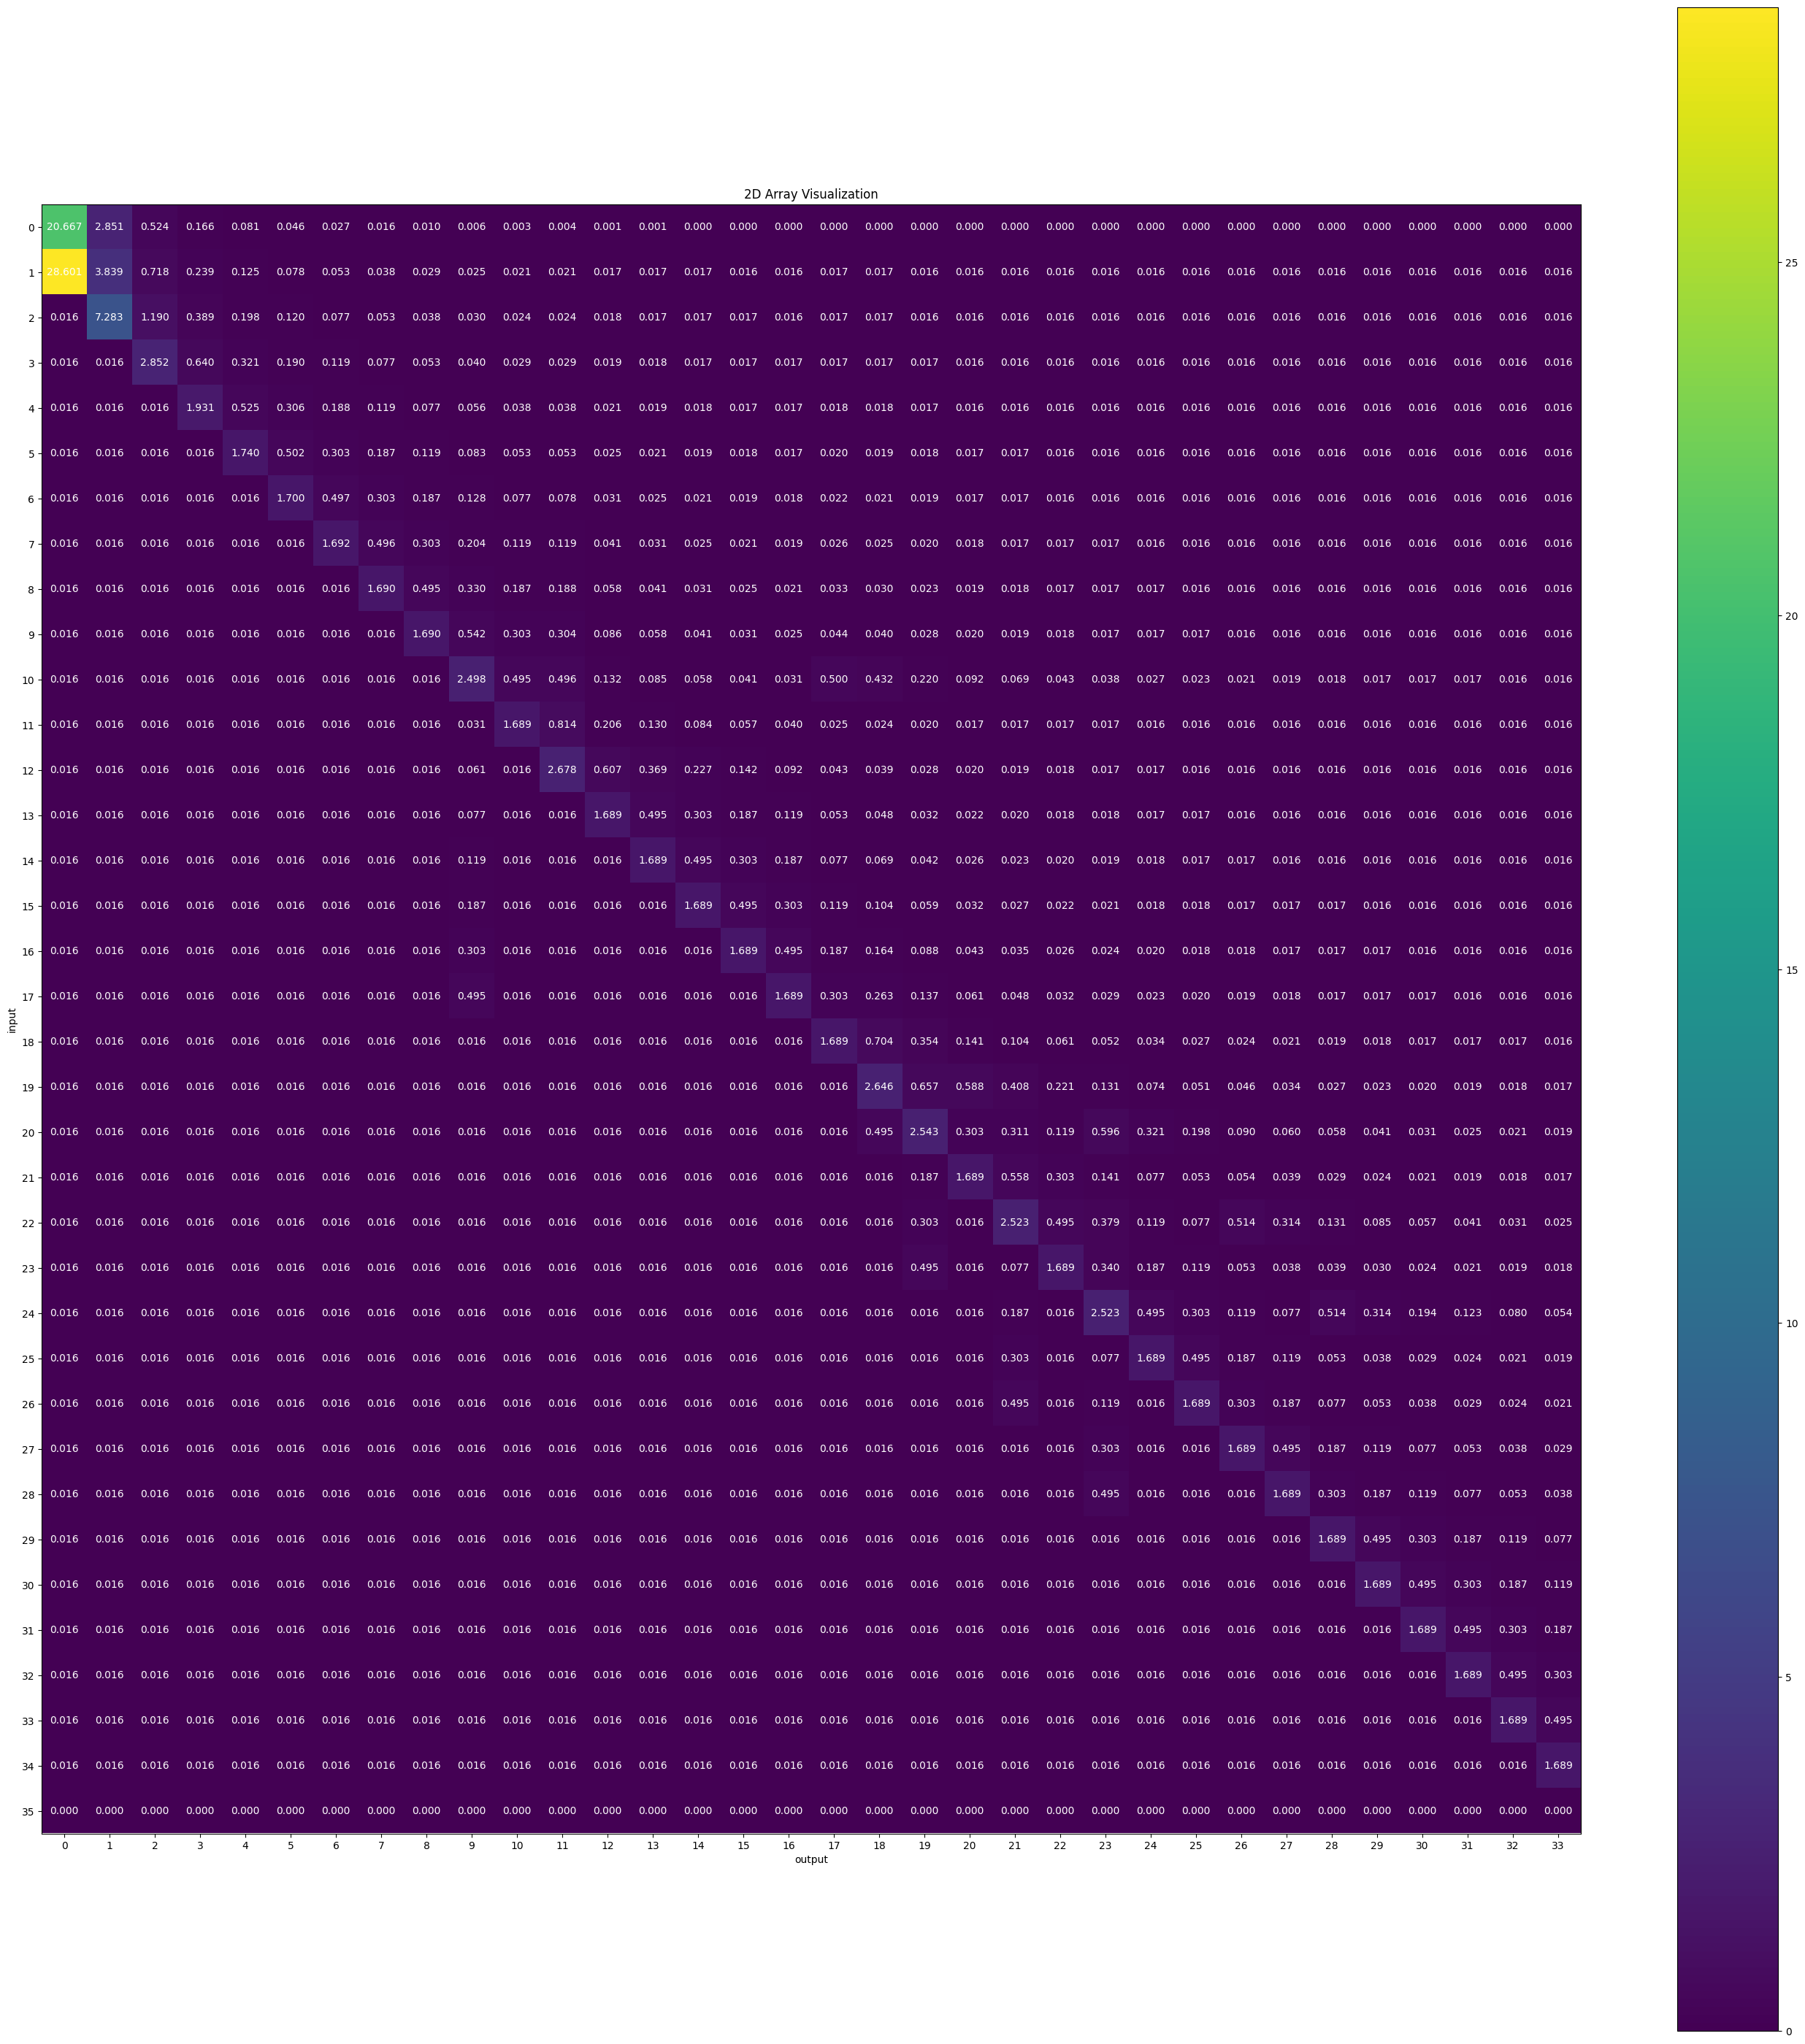

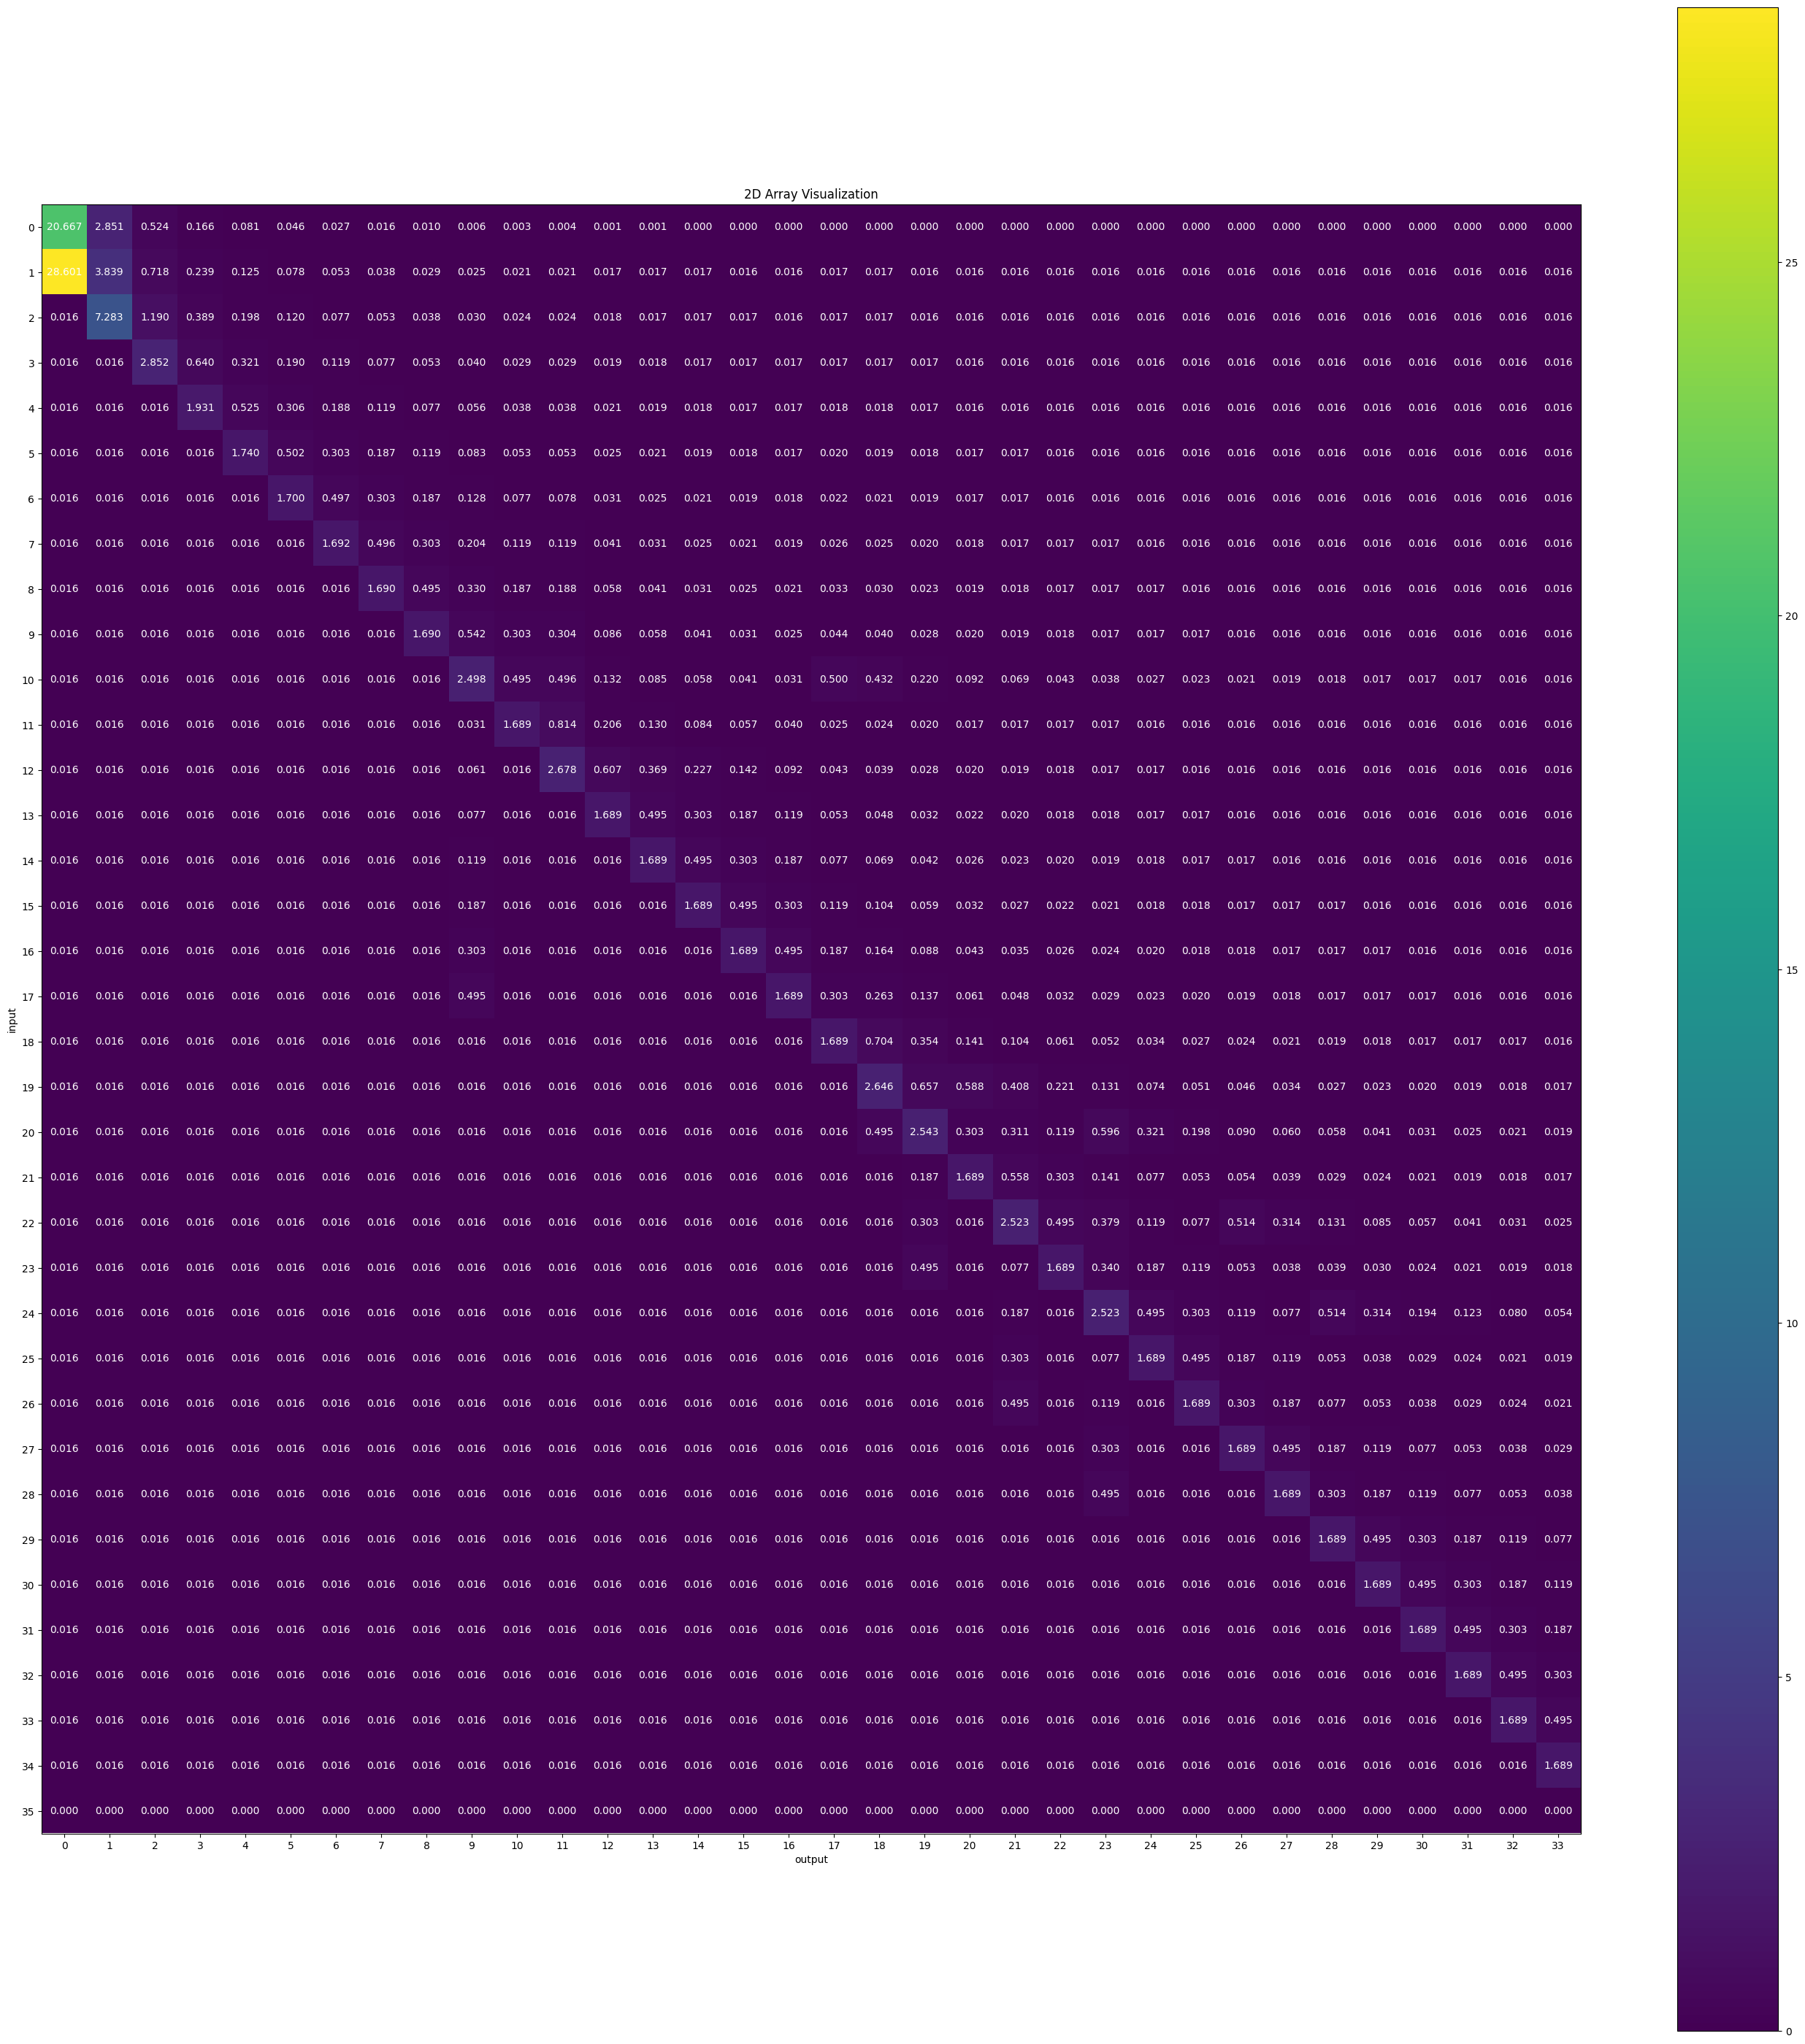

In [16]:
jax_model = BaseCMR.create(item_count, list_length, parameters)
jax_model = experience(jax_model, jnp.array(presentation))

print('Pre-retrieval')
print(jax_model.context.state)
print()

# with jax.disable_jit():
print(outcome_probabilities(jax_model))
print()

# print('Starting retrieval')
# jax_model = start_retrieving(jax_model)
# print(jax_model.context.state)
# print()

# print(outcome_probabilities(jax_model))
# print()

activation_matrix = lax.map(
    lambda _probe: probe(jax_model.mcf, _probe), 
    np.eye(jax_model.mcf.state.shape[0])
    )

visualize_2d_array(jax_model.mcf.state)
visualize_2d_array(activation_matrix)

# orthonormal_activation_matrix = lax.map(
#     lambda _probe: probe(jax_model.mfc, _probe), 
#     np.eye(jax_model.mfc.state.shape[0])
#     )

# # visualize_2d_array(jax_model.mfc.state)
# visualize_2d_array(orthonormal_activation_matrix)

In [ ]:
model.mcf.choice_sensitivity, jax_model.mcf.choice_sensitivity

(1.0, Array(1., dtype=float64, weak_type=True))

In [ ]:
model.mcf.activations(model.context.state())

array([0.03340257, 0.0333553 , 0.03334231, 0.03334357, 0.03335365,
       0.0333733 , 0.03340713, 0.03346404, 0.0335593 , 0.03911181,
       0.03436432, 0.0346263 , 0.03387885, 0.03399214, 0.03428661,
       0.03484166, 0.03580618, 0.040152  , 0.08645815, 0.19347972,
       0.07451223, 0.47107067, 0.1363063 , 1.55350701, 0.36319789,
       0.31388049, 0.45652511, 0.67645703, 0.73207559, 0.03332225,
       0.03332225, 0.03332225, 0.03332225, 0.03332225])

In [ ]:
from jaxcmr.helpers import lb

item_activation = probe(jax_model.mcf, jax_model.context.state)# + lb
item_activation

Array([0.03340259, 0.03335532, 0.03334234, 0.03334359, 0.03335367,
       0.03337332, 0.03340715, 0.03346406, 0.03355932, 0.03911184,
       0.03436434, 0.03462632, 0.03387887, 0.03399216, 0.03428663,
       0.03484168, 0.03580621, 0.04015203, 0.08645824, 0.19347994,
       0.0745123 , 0.47107114, 0.13630644, 1.55350848, 0.36319827,
       0.31388081, 0.45652555, 0.67645768, 1.75516663, 0.03332227,
       0.03332227, 0.03332227, 0.03332227, 0.03332227], dtype=float64)

In [ ]:
np.dot( model.context.state(), model.mcf.memory)

array([0.03340257, 0.0333553 , 0.03334231, 0.03334357, 0.03335365,
       0.0333733 , 0.03340713, 0.03346404, 0.0335593 , 0.03911181,
       0.03436432, 0.0346263 , 0.03387885, 0.03399214, 0.03428661,
       0.03484166, 0.03580618, 0.040152  , 0.08645815, 0.19347972,
       0.07451223, 0.47107067, 0.1363063 , 1.55350701, 0.36319789,
       0.31388049, 0.45652511, 0.67645703, 0.73207559, 0.03332225,
       0.03332225, 0.03332225, 0.03332225, 0.03332225])

In [ ]:
jnp.dot( jax_model.context.state, jax_model.mcf.state)

Array([0.03340259, 0.03335532, 0.03334234, 0.03334359, 0.03335367,
       0.03337332, 0.03340715, 0.03346406, 0.03355932, 0.03911184,
       0.03436434, 0.03462632, 0.03387887, 0.03399216, 0.03428663,
       0.03484168, 0.03580621, 0.04015203, 0.08645824, 0.19347994,
       0.0745123 , 0.47107114, 0.13630644, 1.55350848, 0.36319827,
       0.31388081, 0.45652555, 0.67645768, 1.75516663, 0.03332227,
       0.03332227, 0.03332227, 0.03332227, 0.03332227], dtype=float64)

In [ ]:
jnp.allclose(model.context.state(), jax_model.context.state)

Array(True, dtype=bool)

In [ ]:
jnp.allclose(model.mcf.memory, jax_model.mcf.state)

Array(False, dtype=bool)

In [ ]:
model.mcf.memory[0]

array([2.06670760e+01, 2.85116426e+00, 5.23524399e-01, 1.66228473e-01,
       8.11400585e-02, 4.62411431e-02, 2.73621934e-02, 1.63225951e-02,
       9.75357452e-03, 6.39328772e-03, 3.48539044e-03, 3.50721171e-03,
       8.51048917e-04, 5.08771318e-04, 3.04152037e-04, 1.81827196e-04,
       1.08699352e-04, 3.36557226e-04, 2.90290909e-04, 1.41933525e-04,
       5.32603033e-05, 3.73247619e-05, 1.90344293e-05, 1.52218594e-05,
       7.73847246e-06, 4.62618882e-06, 3.27894022e-06, 1.96020554e-06,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00])

In [ ]:
jax_model.mcf.state[0]

Array([2.06670761e+01, 2.85116431e+00, 5.23524424e-01, 1.66228480e-01,
       8.11400605e-02, 4.62411422e-02, 2.73621922e-02, 1.63225947e-02,
       9.75357438e-03, 6.39328800e-03, 3.48539027e-03, 3.50721186e-03,
       8.51048927e-04, 5.08771343e-04, 3.04152054e-04, 1.81827207e-04,
       1.08699358e-04, 3.36557366e-04, 2.90291038e-04, 1.41933590e-04,
       5.32603303e-05, 3.73247825e-05, 1.90344390e-05, 1.52218705e-05,
       7.73847776e-06, 4.62619198e-06, 3.27894292e-06, 1.96020715e-06,
       1.36141210e-06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00], dtype=float64)

### Exploration

In [ ]:
outcome_probabilities(jax_model)[1].item()

0.0048461444812928365

In [ ]:
model.outcome_probabilities()[1].item()

0.005694291635298433